# Stage 2 — linear baselines (PCA / dPCA / GPFA)

Visualize the artifacts written by `src/02_baseline_linear.py`. CA1 and PFC are
kept separate throughout.

1. **PCA** — scree / cumulative variance; PC1-PC2-PC3 scores colored by condition
2. **dPCA** — variance split into space / condition / interaction, across subjects
3. **GPFA** — example latent trajectories, novel vs. familiar

Run `pixi run python src/02_baseline_linear.py` first if artifacts are missing.


## Setup

In [1]:
import sys, pathlib
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "common" / "config.py").exists())
for _d in ("common", "000447"):
    sys.path.insert(0, str(_root / "src" / _d))
import numpy as np
import matplotlib.pyplot as plt
from config import processed_dir, BIN_SIZE_S
DATA_PROCESSED = processed_dir("000447")
BIN_MS = int(BIN_SIZE_S * 1000)
plt.rcParams["figure.dpi"] = 100
COND_COLOR = {"novel": "tab:red", "familiar": "tab:blue"}
print("bin size:", BIN_MS, "ms")

bin size: 1000 ms


## 1. PCA — variance and low-D scores
Pick one subject/region for the scores plot; scree shown for the same file.

0 pca_JDS-NFN-AM2_CA1_1000ms.npz
1 pca_JDS-NFN-AM2_PFC_1000ms.npz
2 pca_JDS-NFN-JS17_CA1_1000ms.npz
3 pca_JDS-NFN-JS17_PFC_1000ms.npz
4 pca_JDS-NFN-JS21_CA1_1000ms.npz
5 pca_JDS-NFN-JS21_PFC_1000ms.npz
6 pca_JDS-NFN-JS34_CA1_1000ms.npz
7 pca_JDS-NFN-JS34_PFC_1000ms.npz
8 pca_JDS-NFN-ZT2_CA1_1000ms.npz
9 pca_JDS-NFN-ZT2_PFC_1000ms.npz


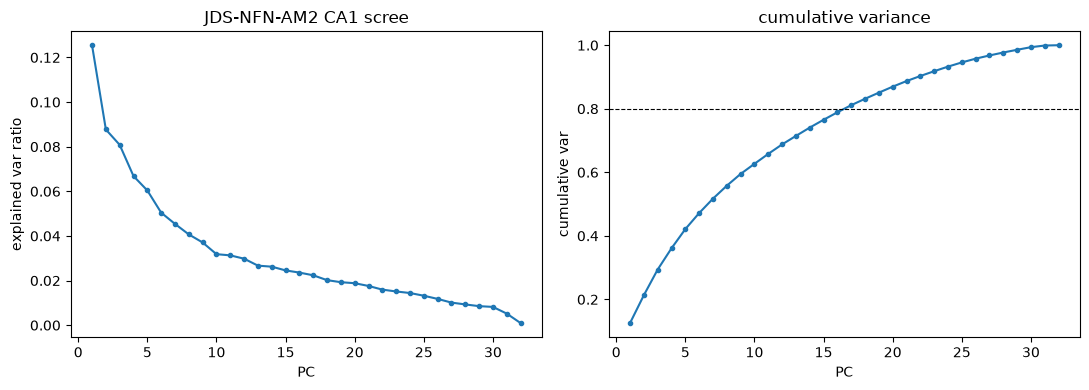

In [2]:
pca_files = sorted(DATA_PROCESSED.glob(f"pca_*_{BIN_MS}ms.npz"))
for i, f in enumerate(pca_files): print(i, f.name)
p = np.load(pca_files[0], allow_pickle=False)
subject, region = str(p["subject"]), str(p["region"])
evr = p["explained_variance_ratio"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(1, len(evr) + 1), evr, "o-", ms=3)
axes[0].set_xlabel("PC"); axes[0].set_ylabel("explained var ratio")
axes[0].set_title(f"{subject} {region} scree")
axes[1].plot(np.arange(1, len(evr) + 1), np.cumsum(evr), "o-", ms=3)
axes[1].axhline(0.8, color="k", ls="--", lw=0.8)
axes[1].set_xlabel("PC"); axes[1].set_ylabel("cumulative var")
axes[1].set_title("cumulative variance")
plt.tight_layout()

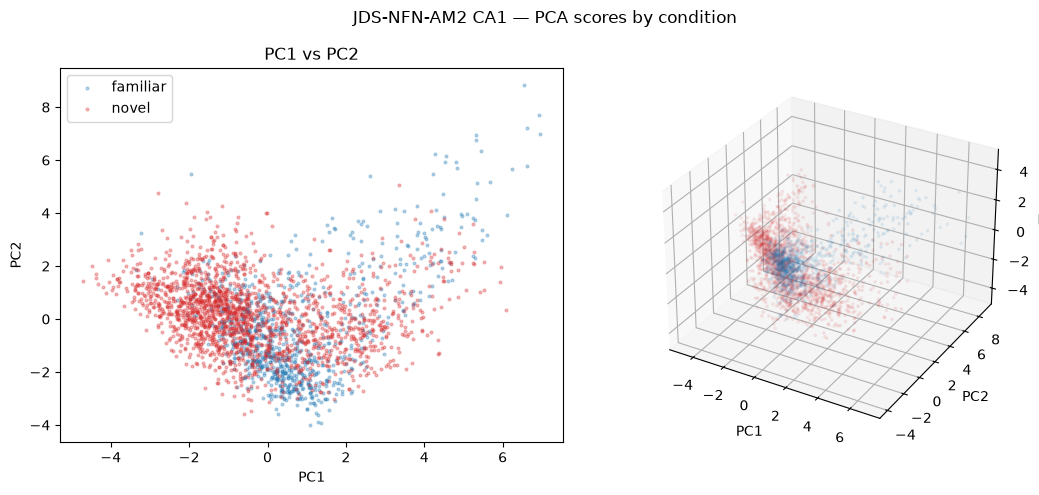

In [3]:
scores, condition = p["scores"], p["condition"]
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for c in np.unique(condition):
    m = condition == c
    axes[0].scatter(scores[m, 0], scores[m, 1], s=4, alpha=0.3,
                    color=COND_COLOR.get(c), label=c)
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend(); axes[0].set_title("PC1 vs PC2")
ax = fig.add_subplot(1, 2, 2, projection="3d")
for c in np.unique(condition):
    m = condition == c
    ax.scatter(scores[m, 0], scores[m, 1], scores[m, 2], s=3, alpha=0.3,
               color=COND_COLOR.get(c), label=c)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
axes[1].remove()
fig.suptitle(f"{subject} {region} — PCA scores by condition")
plt.tight_layout()

## 2. dPCA — variance demixing across all subjects

Fraction of variance captured by components that depend on **space**, on
**condition** (novel/familiar), and on their **interaction**, per region. This
quantifies how much of the novel-vs-familiar difference is a genuine
space-dependent remap (interaction) vs. a global condition shift.

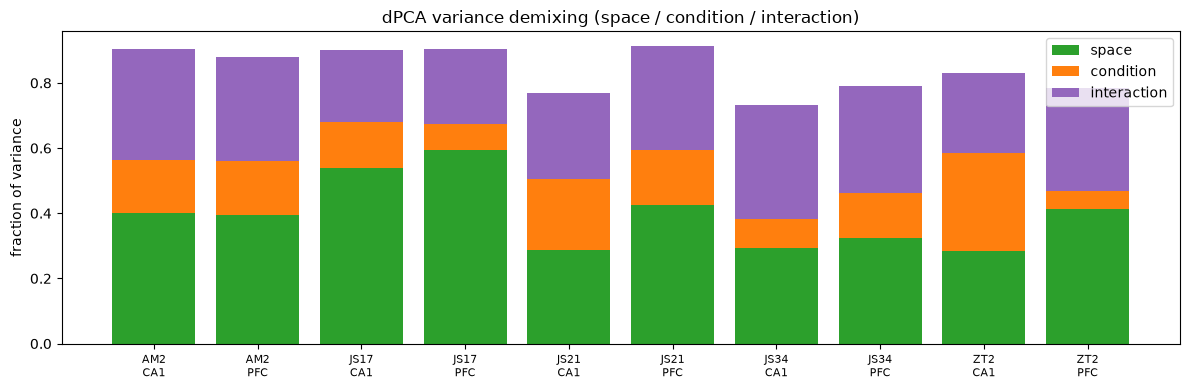

In [4]:
dpca_files = sorted(DATA_PROCESSED.glob(f"dpca_*_{BIN_MS}ms.npz"))
rows = []
for f in dpca_files:
    d = np.load(f, allow_pickle=False)
    rows.append((str(d["subject"]), str(d["region"]),
                 float(d["evr_s"].sum()), float(d["evr_c"].sum()), float(d["evr_sc"].sum())))
labels = [f"{s.split('-')[-1]}\n{r}" for s, r, *_ in rows]
S = np.array([r[2] for r in rows]); C = np.array([r[3] for r in rows]); SC = np.array([r[4] for r in rows])
x = np.arange(len(rows))
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x, S, label="space", color="tab:green")
ax.bar(x, C, bottom=S, label="condition", color="tab:orange")
ax.bar(x, SC, bottom=S + C, label="interaction", color="tab:purple")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("fraction of variance"); ax.legend()
ax.set_title("dPCA variance demixing (space / condition / interaction)")
plt.tight_layout()

## 3. GPFA — latent trajectories

Trial-averaged GPFA latent trajectory (first 3 dims) for one region, split by
condition. Each trial is a fixed-length segment; we average latents across
trials within a condition.

0 gpfa_JDS-NFN-AM2_CA1.npz
1 gpfa_JDS-NFN-AM2_PFC.npz
2 gpfa_JDS-NFN-JS17_CA1.npz
3 gpfa_JDS-NFN-JS17_PFC.npz
4 gpfa_JDS-NFN-JS21_CA1.npz
5 gpfa_JDS-NFN-JS21_PFC.npz
6 gpfa_JDS-NFN-JS34_CA1.npz
7 gpfa_JDS-NFN-JS34_PFC.npz
8 gpfa_JDS-NFN-ZT2_CA1.npz
9 gpfa_JDS-NFN-ZT2_PFC.npz


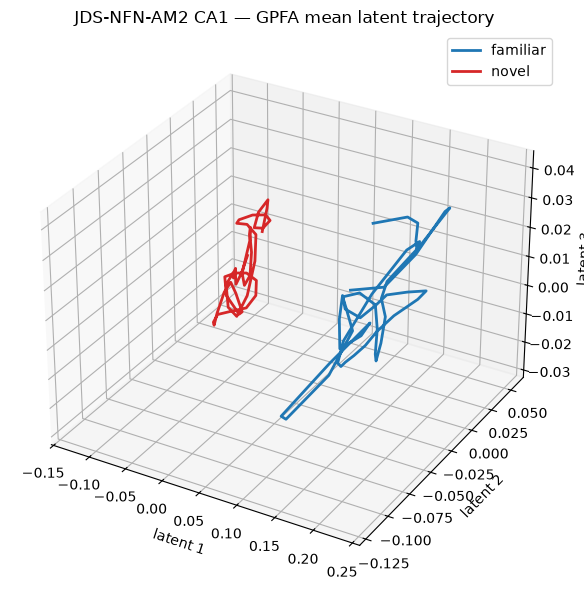

In [5]:
gpfa_files = sorted(DATA_PROCESSED.glob("gpfa_*.npz"))
if not gpfa_files:
    print("no GPFA artifacts yet — run: pixi run python src/02_baseline_linear.py --method gpfa")
else:
    for i, f in enumerate(gpfa_files): print(i, f.name)
    g = np.load(gpfa_files[0], allow_pickle=False)
    lat = g["latents"]              # (n_trials, x_dim, n_bins)
    tcond = g["trial_condition"]
    subject, region = str(g["subject"]), str(g["region"])
    fig = plt.figure(figsize=(6, 6)); ax = fig.add_subplot(111, projection="3d")
    for c in np.unique(tcond):
        mean_traj = lat[tcond == c].mean(axis=0)   # (x_dim, n_bins)
        ax.plot(mean_traj[0], mean_traj[1], mean_traj[2],
                color=COND_COLOR.get(c), label=c, lw=2)
    ax.set_xlabel("latent 1"); ax.set_ylabel("latent 2"); ax.set_zlabel("latent 3")
    ax.legend(); ax.set_title(f"{subject} {region} — GPFA mean latent trajectory")
    plt.tight_layout()

---
**Next:** stage 3 (`src/03_nonlinear_embedding.py`) — CEBRA (behavior-aligned),
UMAP, Isomap — to compare against these linear baselines.